# **Análisis realizados**
A continuación, se exponen todos los análisis que se han realizado:
-   **Arquitecturas seleccionadas**. Se han utilizado las siguientes arquitecturas:
    -   EfficientNetBX. Se realizan pruebas con EfficientNetB0, B1 y B2. No se observan diferencias en el desempeño de los modelos, empleando igualdad de semillas.
    -   ResNet50 y ResNet150. Se realizan pruebas, pero desempeño igualmente inferior al resto de modelos.
    -   Redes Convolucionales (CNN) y Convolucionales con conexiones Residuales. Se prueban ambas arquitecturas, obteniendo un desempeño algo superior para esta última.
-   **Generación de datos**. Se realizan las siguientes alternativas:
    -   Parámetros de lectura de audio. Se realizan:
        -   `Sample_Rate`. Observé que en algunos artículos se utilizaban 4096Hz y 8192Hz. He probado ambas, pero no se observa mucha diferencia. Con igualdad de semillas, 4096Hz mejor.
        -   Segundos (s). Se prueba la división mediante 6s, 7s, 8s y hasta 9s. Destacan 7s, aunque de igual forma, diferencias muy leves entre sí.
    -   Extracción de Características. Se realizan:
        -   Se emplea entrada multimodal, empleando MFCC, espectrogramas normales y espectrogramas de Mel. Desconozco si, bien sea por haber tenido que reducir considerablemente el `batch_size` o porque no permite obtener un mejor desempeño, pero los resultados no mejoran a usar únicamente espectrogramas de Mel. En este sentido, considero que es mucho más sencillo y eficiente emplear únicamente los espectrogramas de Mel (además de explicabiidad).
        -   Parámetros de Construcción. Se prueba la variación de parámetros de generación de espectrogramas, pero diferencias irrisorias. Me quedo con la configuración actualmente seleccionada.
    -   Aumento de datos. Utilizando una semilla idéntica para separar el conjunto de datos, he observado que aplicar CBA empeora el desempeño en comparación a usar aumento de datos tradicional y Focal Loss. Adicionalmente, uso `spec_augment` y veo que da algo mejor de desempeño (sobre un 1 punto para el ICBHI Score).
-   **Función de Pérdida**. He realizado múltiples pruebas con Focal Loss y CategoricalCrossEntropy con pesos. De forma generalizada, obtengo un mejor desempeño con Focal Loss. Además, sobre esta función se utiliza el parámetro `gamma`, el cual se ha iterado entre 1.0 y 2.0 (saltando de 0.5 en 0.5). 
-   **Entrenamiento**. He probado el entrenamiento en 3 fases: Warm-Up, Training y Pequeño Tuneo y es el tipo de entrenamiento que mejor entrenamiento me devuelve de forma generalizada. Mantengo este flujo.
-   **Fine Tuning por Estetoscopio**. Probé a hacer fine tuning sobre el estetoscopio y obtuve cerca de un 1 punto de desempeño. Ahora, no termino de ver su aplicabilidad en producción... ¿Disponer de un modelo por Estetoscopio?¿Incluso teniendo tan pocos datos?

In [1]:
import os
import re
import matplotlib.pyplot as plt


def plot_training_metrics(log_files, labels=None, figsize=(20, 24)):
    """
    Dibuja la evolución del ICBHI Score, Recall y Specificity para uno o
    varios ficheros de entrenamiento.

    Parameters
    ----------
    log_files : str | list[str]
        Ruta o lista de rutas a los logs.

    labels : list[str], optional
        Etiquetas para la leyenda. Si no se indican se utiliza el nombre
        del fichero.

    figsize : tuple
        Tamaño de la figura.
    """

    if isinstance(log_files, str):
        log_files = [log_files]

    if labels is None:
        labels = [os.path.basename(f) for f in log_files]

    pattern = re.compile(
        r"ICBHI Score:\s*([\d.]+)\s*-\s*Sensitivity:\s*([\d.]+)\s*-\s*Specificity:\s*([\d.]+)"
    )

    # -------- Figura (3 filas x 1 columna) --------
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True
    )

    metrics = [
        ("ICBHI Score", []),
        ("Recall (Sensitivity)", []),
        ("Specificity", [])
    ]

    # -------- Leer cada fichero --------
    for log_file, label in zip(log_files, labels):

        icbhi = []
        recall = []
        specificity = []

        with open(log_file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    icbhi.append(float(match.group(1)))
                    recall.append(float(match.group(2)))
                    specificity.append(float(match.group(3)))

        epochs = range(1, len(icbhi) + 1)

        axes[0].plot(
            epochs,
            icbhi,
            linewidth=2,
            marker="o",
            markersize=4,
            label=label
        )

        axes[1].plot(
            epochs,
            recall,
            linewidth=2,
            marker="o",
            markersize=4,
            label=label
        )

        axes[2].plot(
            epochs,
            specificity,
            linewidth=2,
            marker="o",
            markersize=4,
            label=label
        )

    # -------- Formato --------
    titles = [
        "ICBHI Score",
        "Recall (Sensitivity)",
        "Specificity"
    ]

    ylabels = [
        "ICBHI Score",
        "Recall",
        "Specificity"
    ]

    for ax, title, ylabel in zip(axes, titles, ylabels):

        ax.set_title(title, fontsize=20, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=15)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.tick_params(axis="both", labelsize=13)
        ax.legend(fontsize=11)
        ax.set_xlim(left=1)

    axes[2].set_xlabel("Epoch", fontsize=16)

    # Límites opcionales (descomenta si quieres la misma escala siempre)
    # axes[0].set_ylim(0.45, 0.75)
    # axes[1].set_ylim(0.20, 0.60)
    # axes[2].set_ylim(0.70, 0.90)

    plt.tight_layout(pad=3.5)
    plt.show()

## **Variación de Semillas de la Red**
Habiendo establecido todos los parámetros, intento variar las semillas de inicialización de las neuronas de la red.

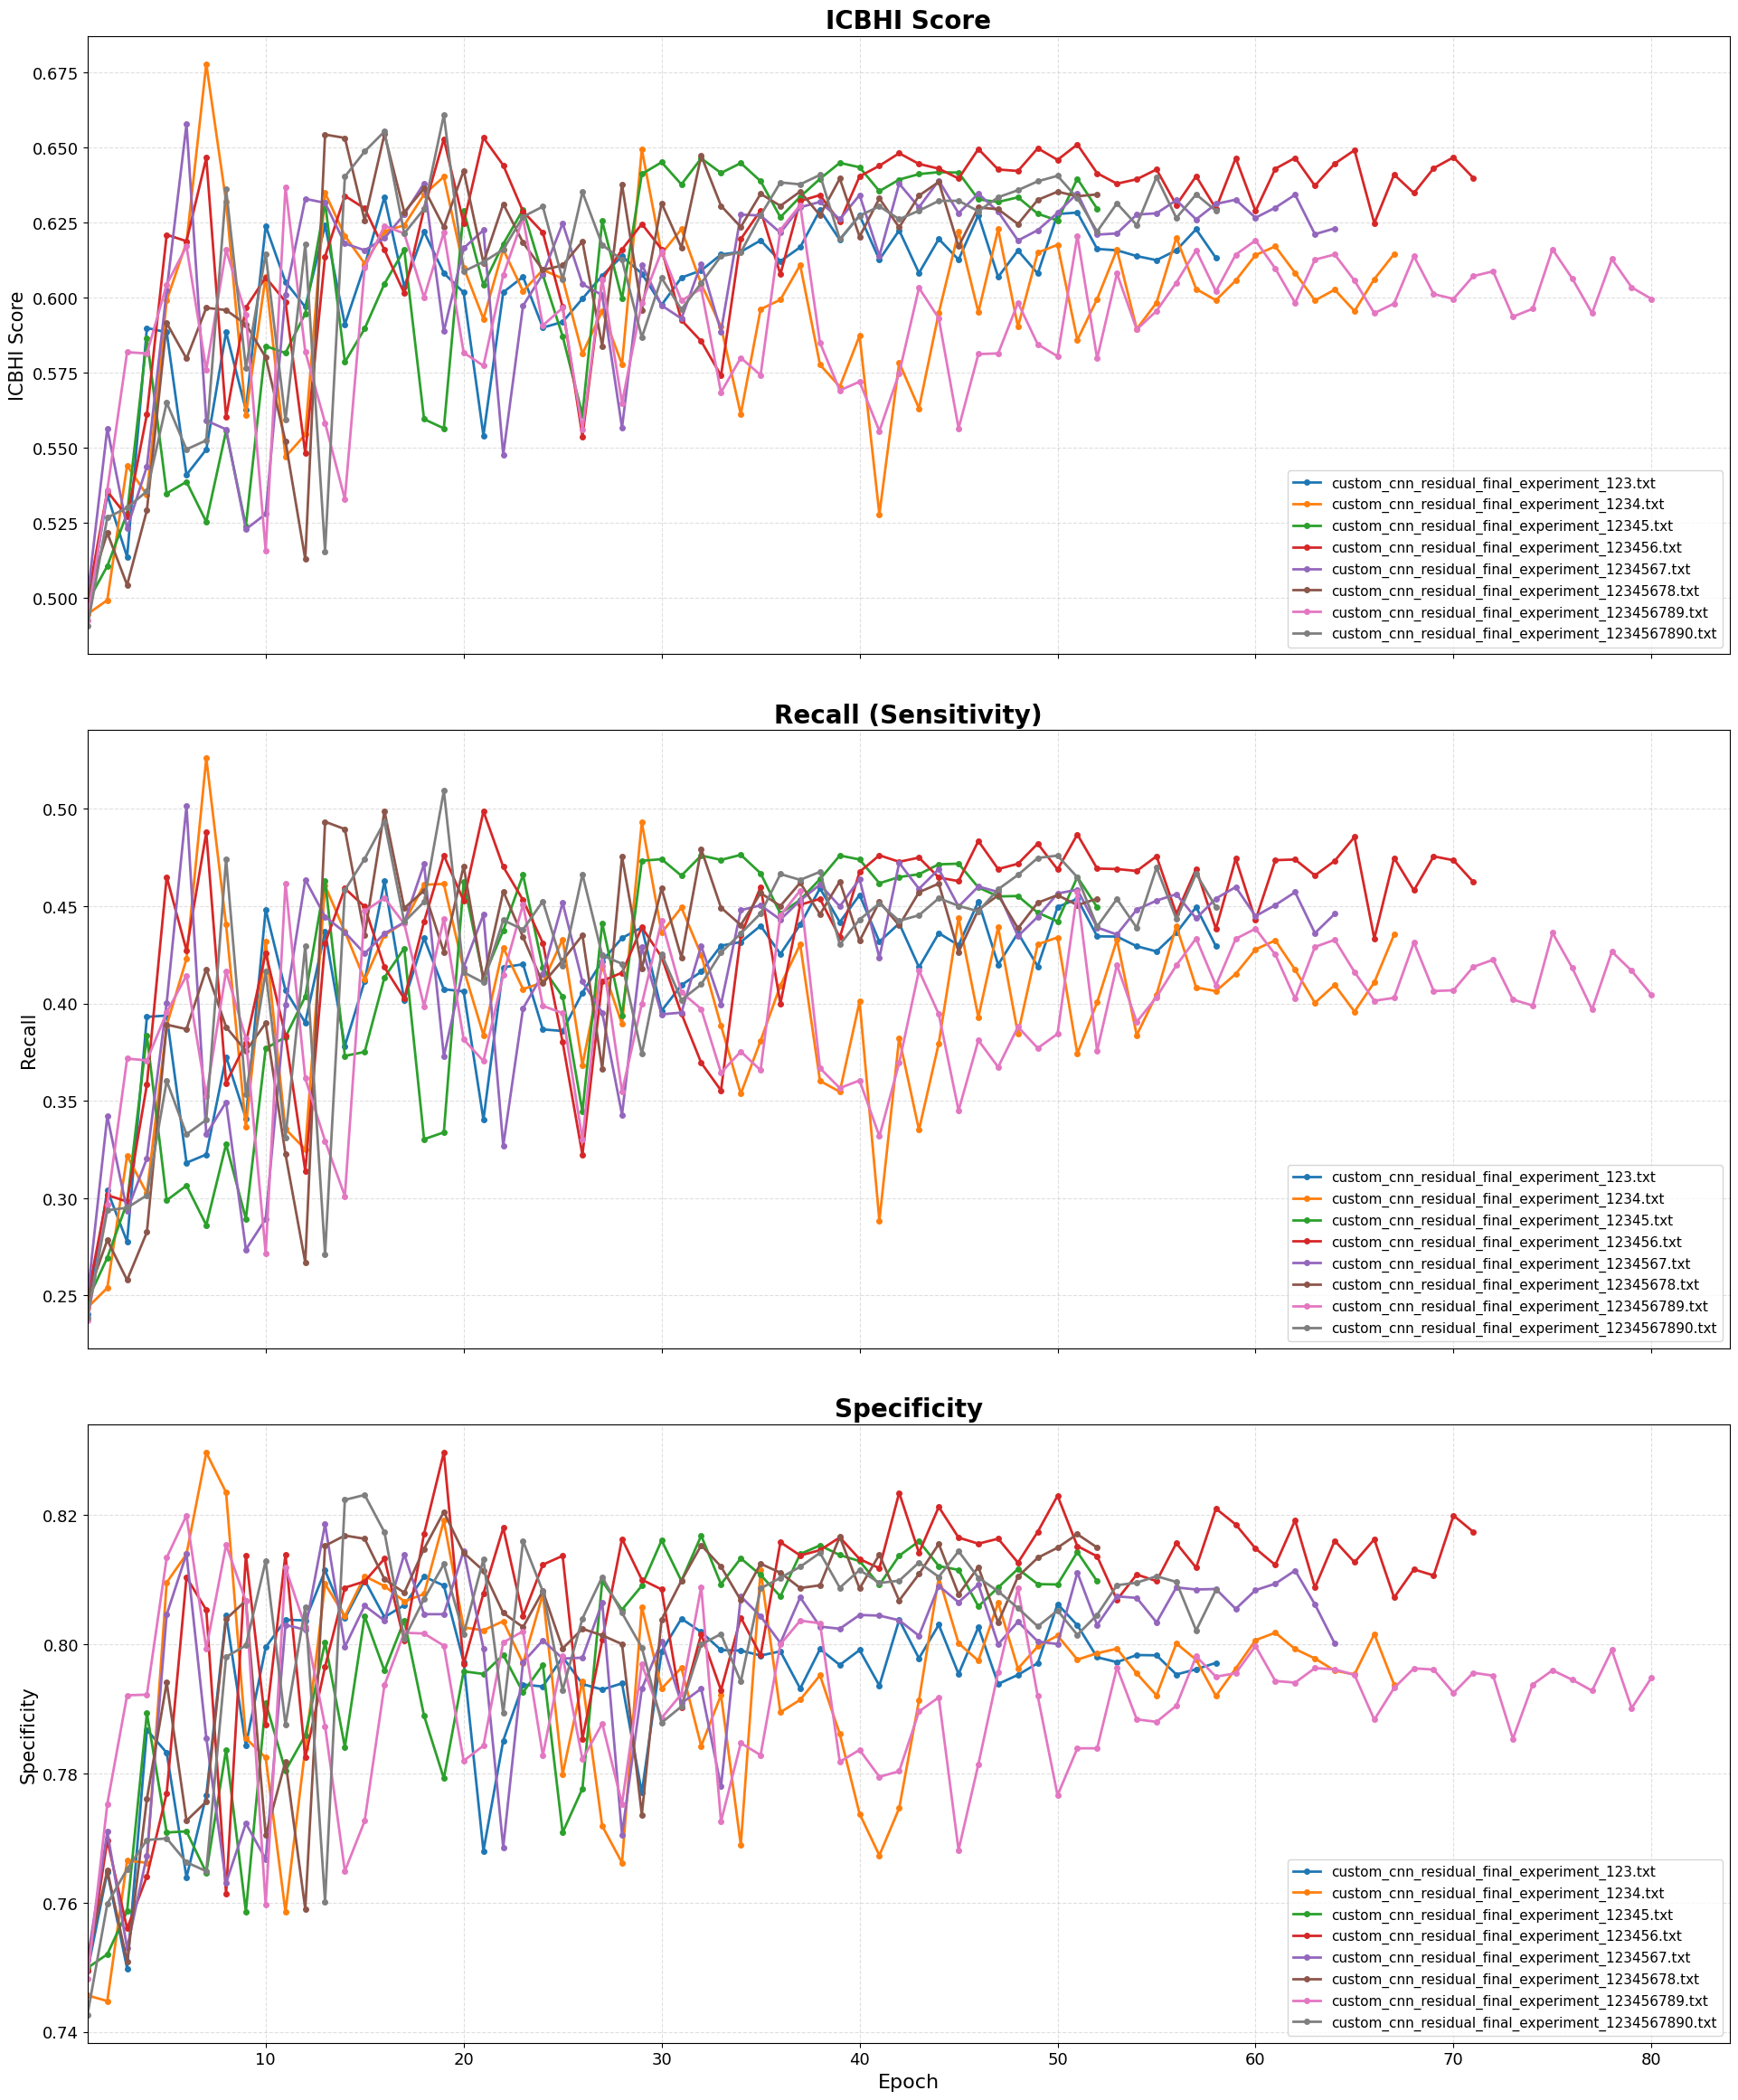

In [2]:
# Obtengo todos los ficheros existentes en un directorio y los paso a la función plot_training_metrics
log_dir = '/app/src/testing/Semilla Último Intento Pesos'
log_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if f.endswith('.txt')]
labels_files = [os.path.basename(f) for f in log_files]

# Ejecuto la función plot_training_metrics con los ficheros obtenidos:
plot_training_metrics(log_files, labels=labels_files)

## **Variación del desempeño variando división**
Se realizan pruebas para ver el desempeño del modelo dividiendo el conjunto de datos de diferentes formas:

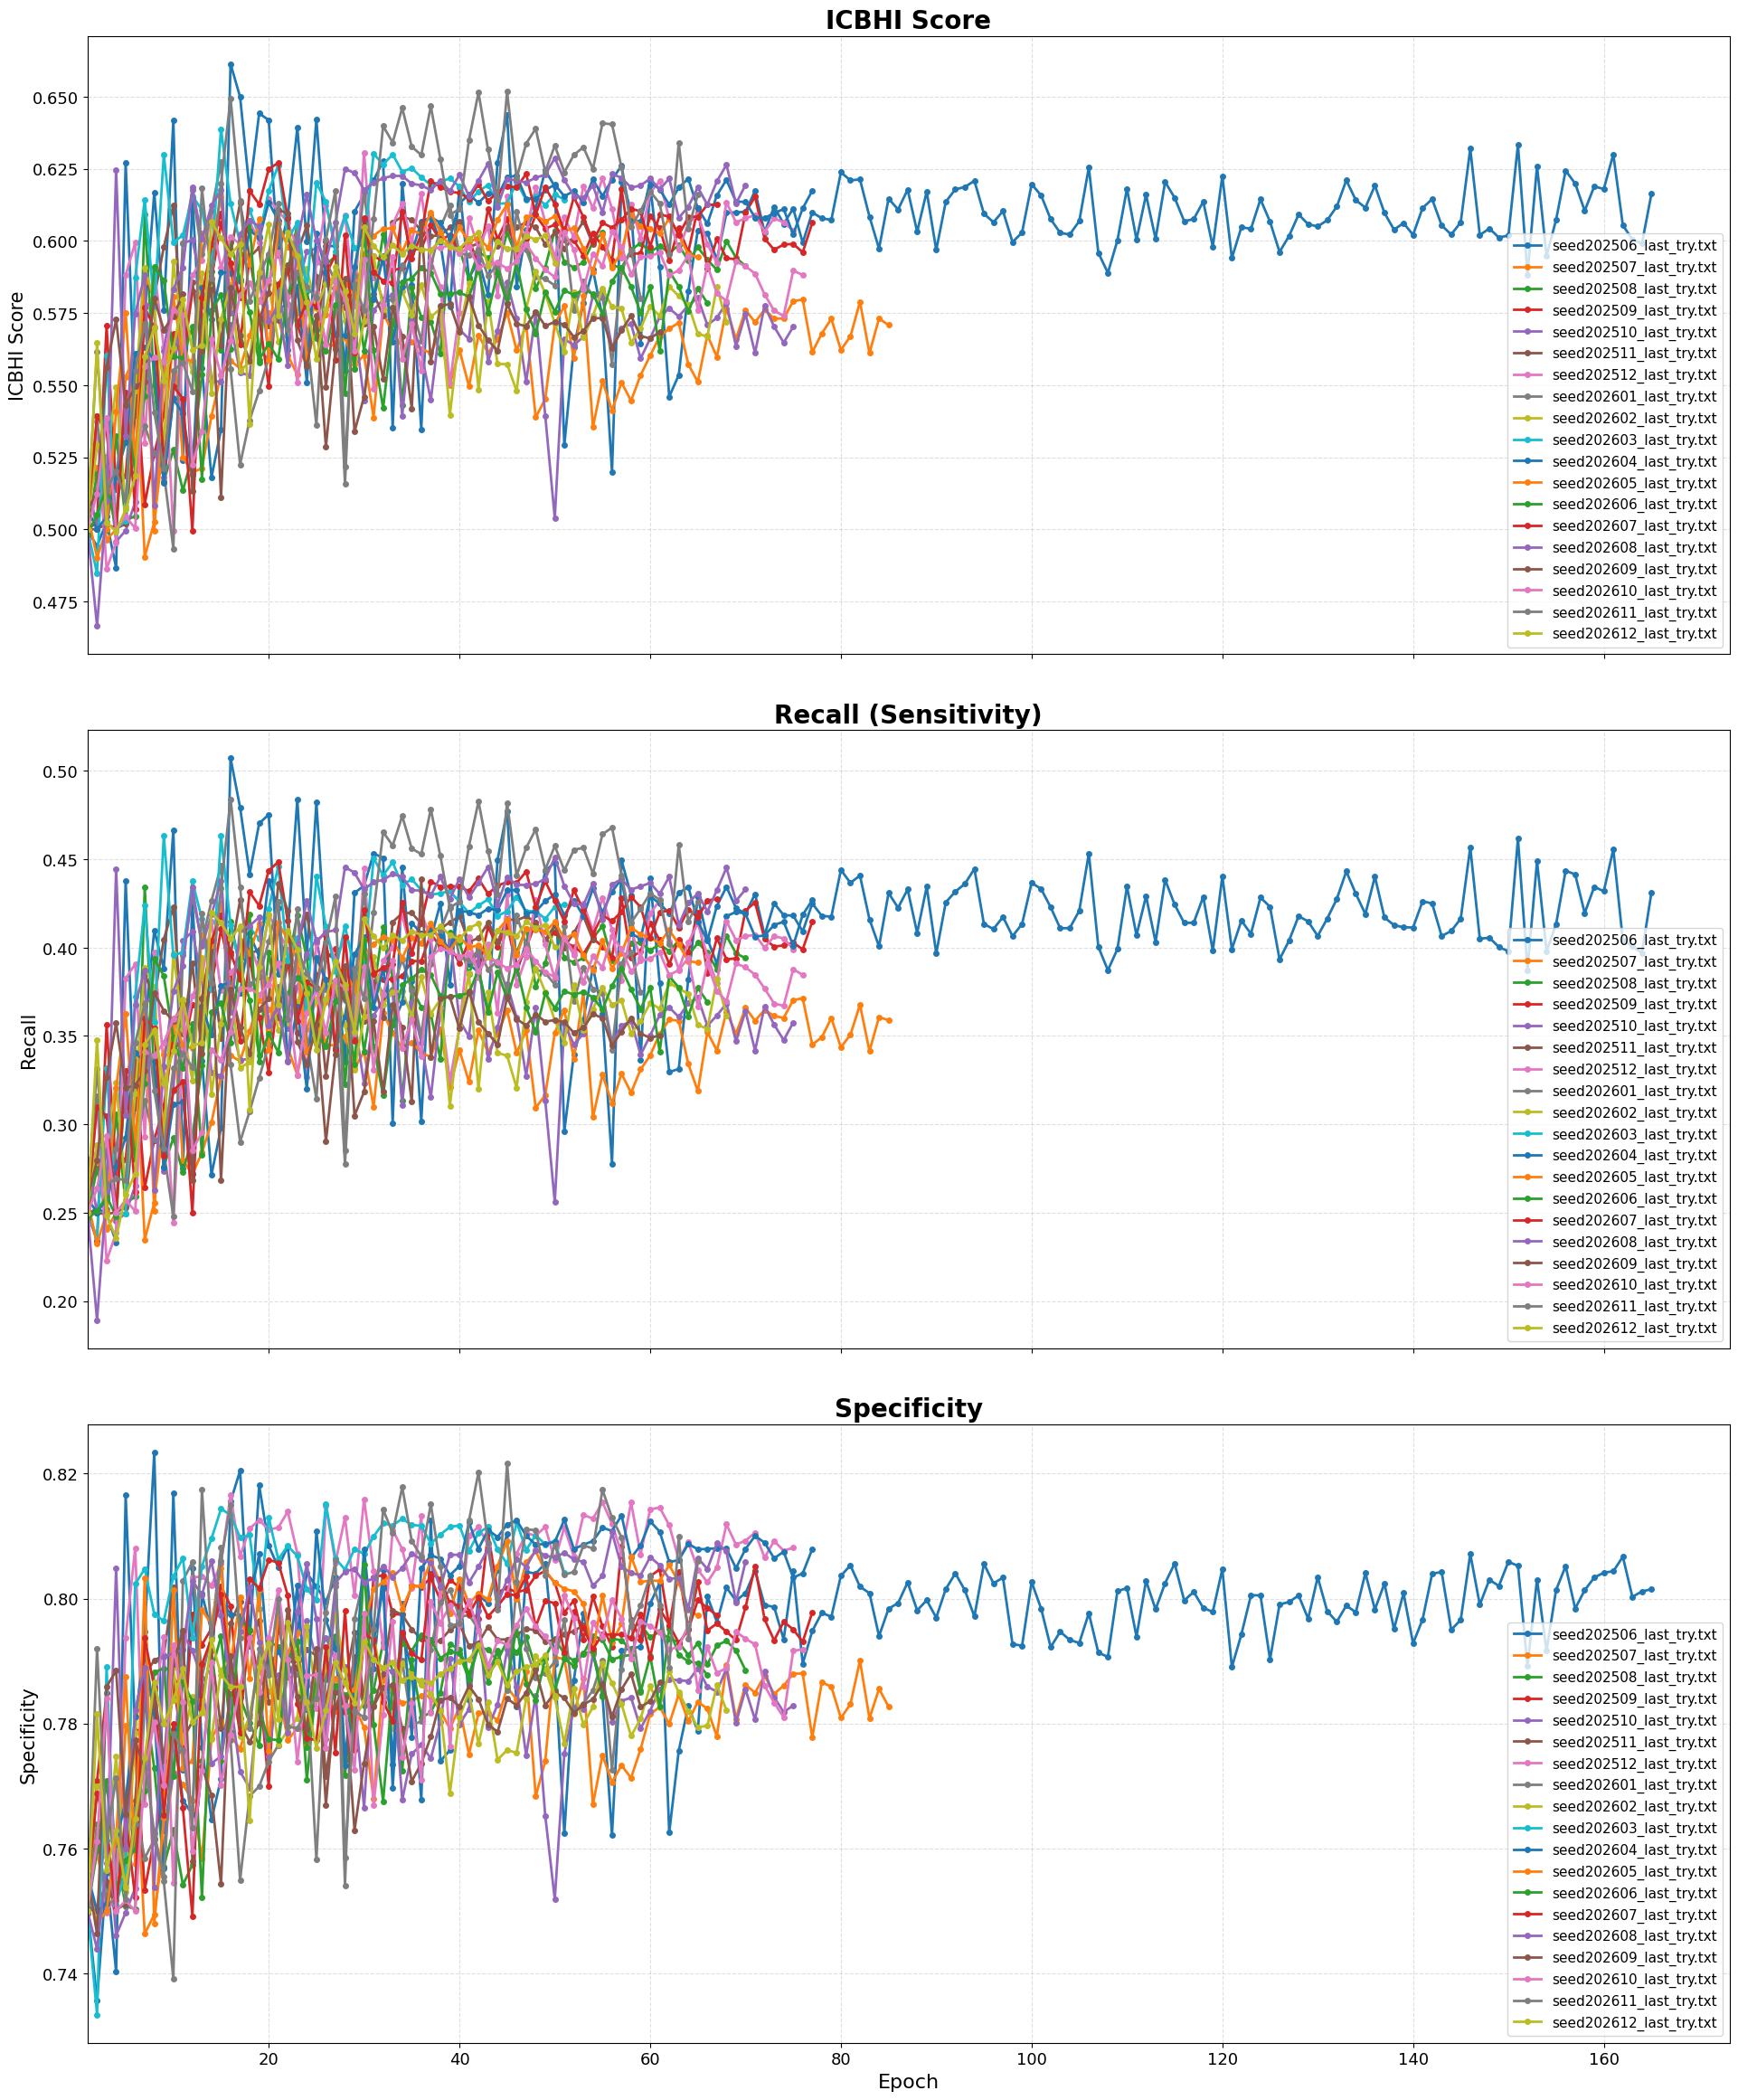

In [3]:
# Obtengo todos los ficheros existentes en un directorio y los paso a la función plot_training_metrics
log_dir = '/app/src/testing/Ultimo intento'
log_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if f.endswith('.txt')]
labels_files = [os.path.basename(f) for f in log_files]

# Ejecuto la función plot_training_metrics con los ficheros obtenidos:
plot_training_metrics(log_files, labels=labels_files)

## **Variación de Duración**
Se varía el número de segundos:

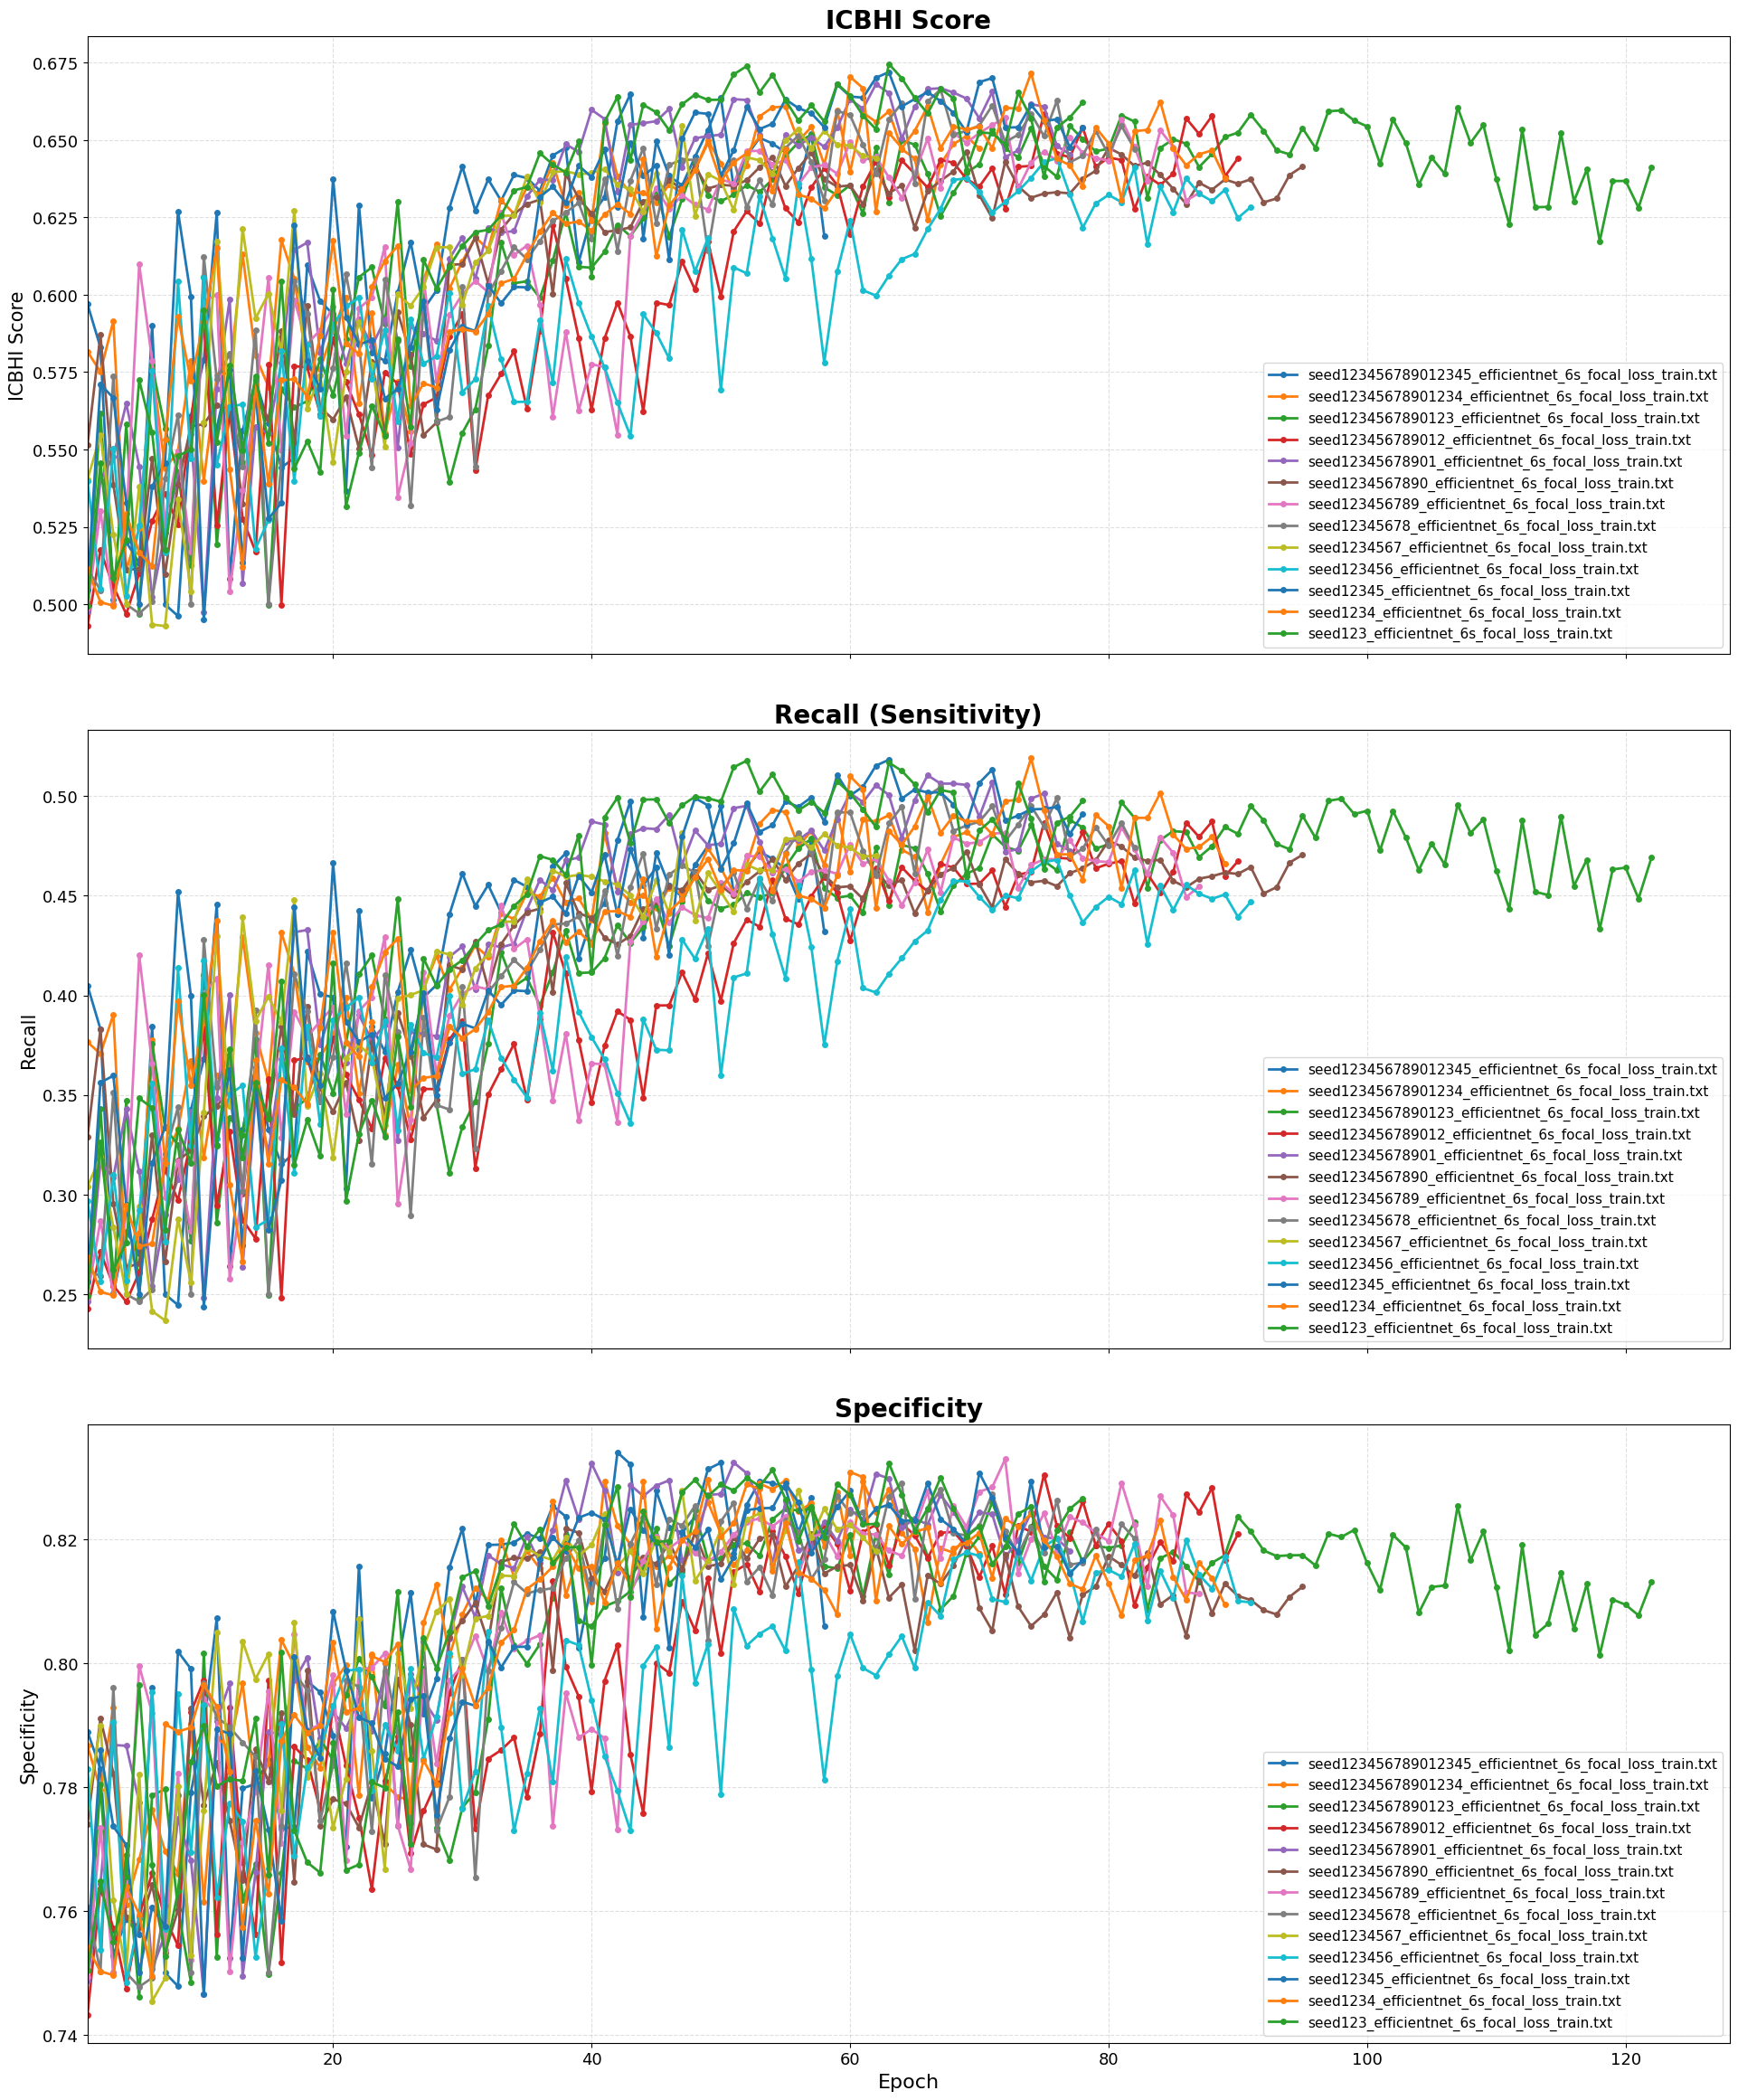

In [4]:
# Obtengo todos los ficheros existentes en un directorio y los paso a la función plot_training_metrics
log_dir = '/app/src/testing/Semilla EfficientNet Focal Loss 6s'
log_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if f.endswith('.txt')]
labels_files = [os.path.basename(f) for f in log_files]

# Ejecuto la función plot_training_metrics con los ficheros obtenidos:
plot_training_metrics(log_files, labels=labels_files)

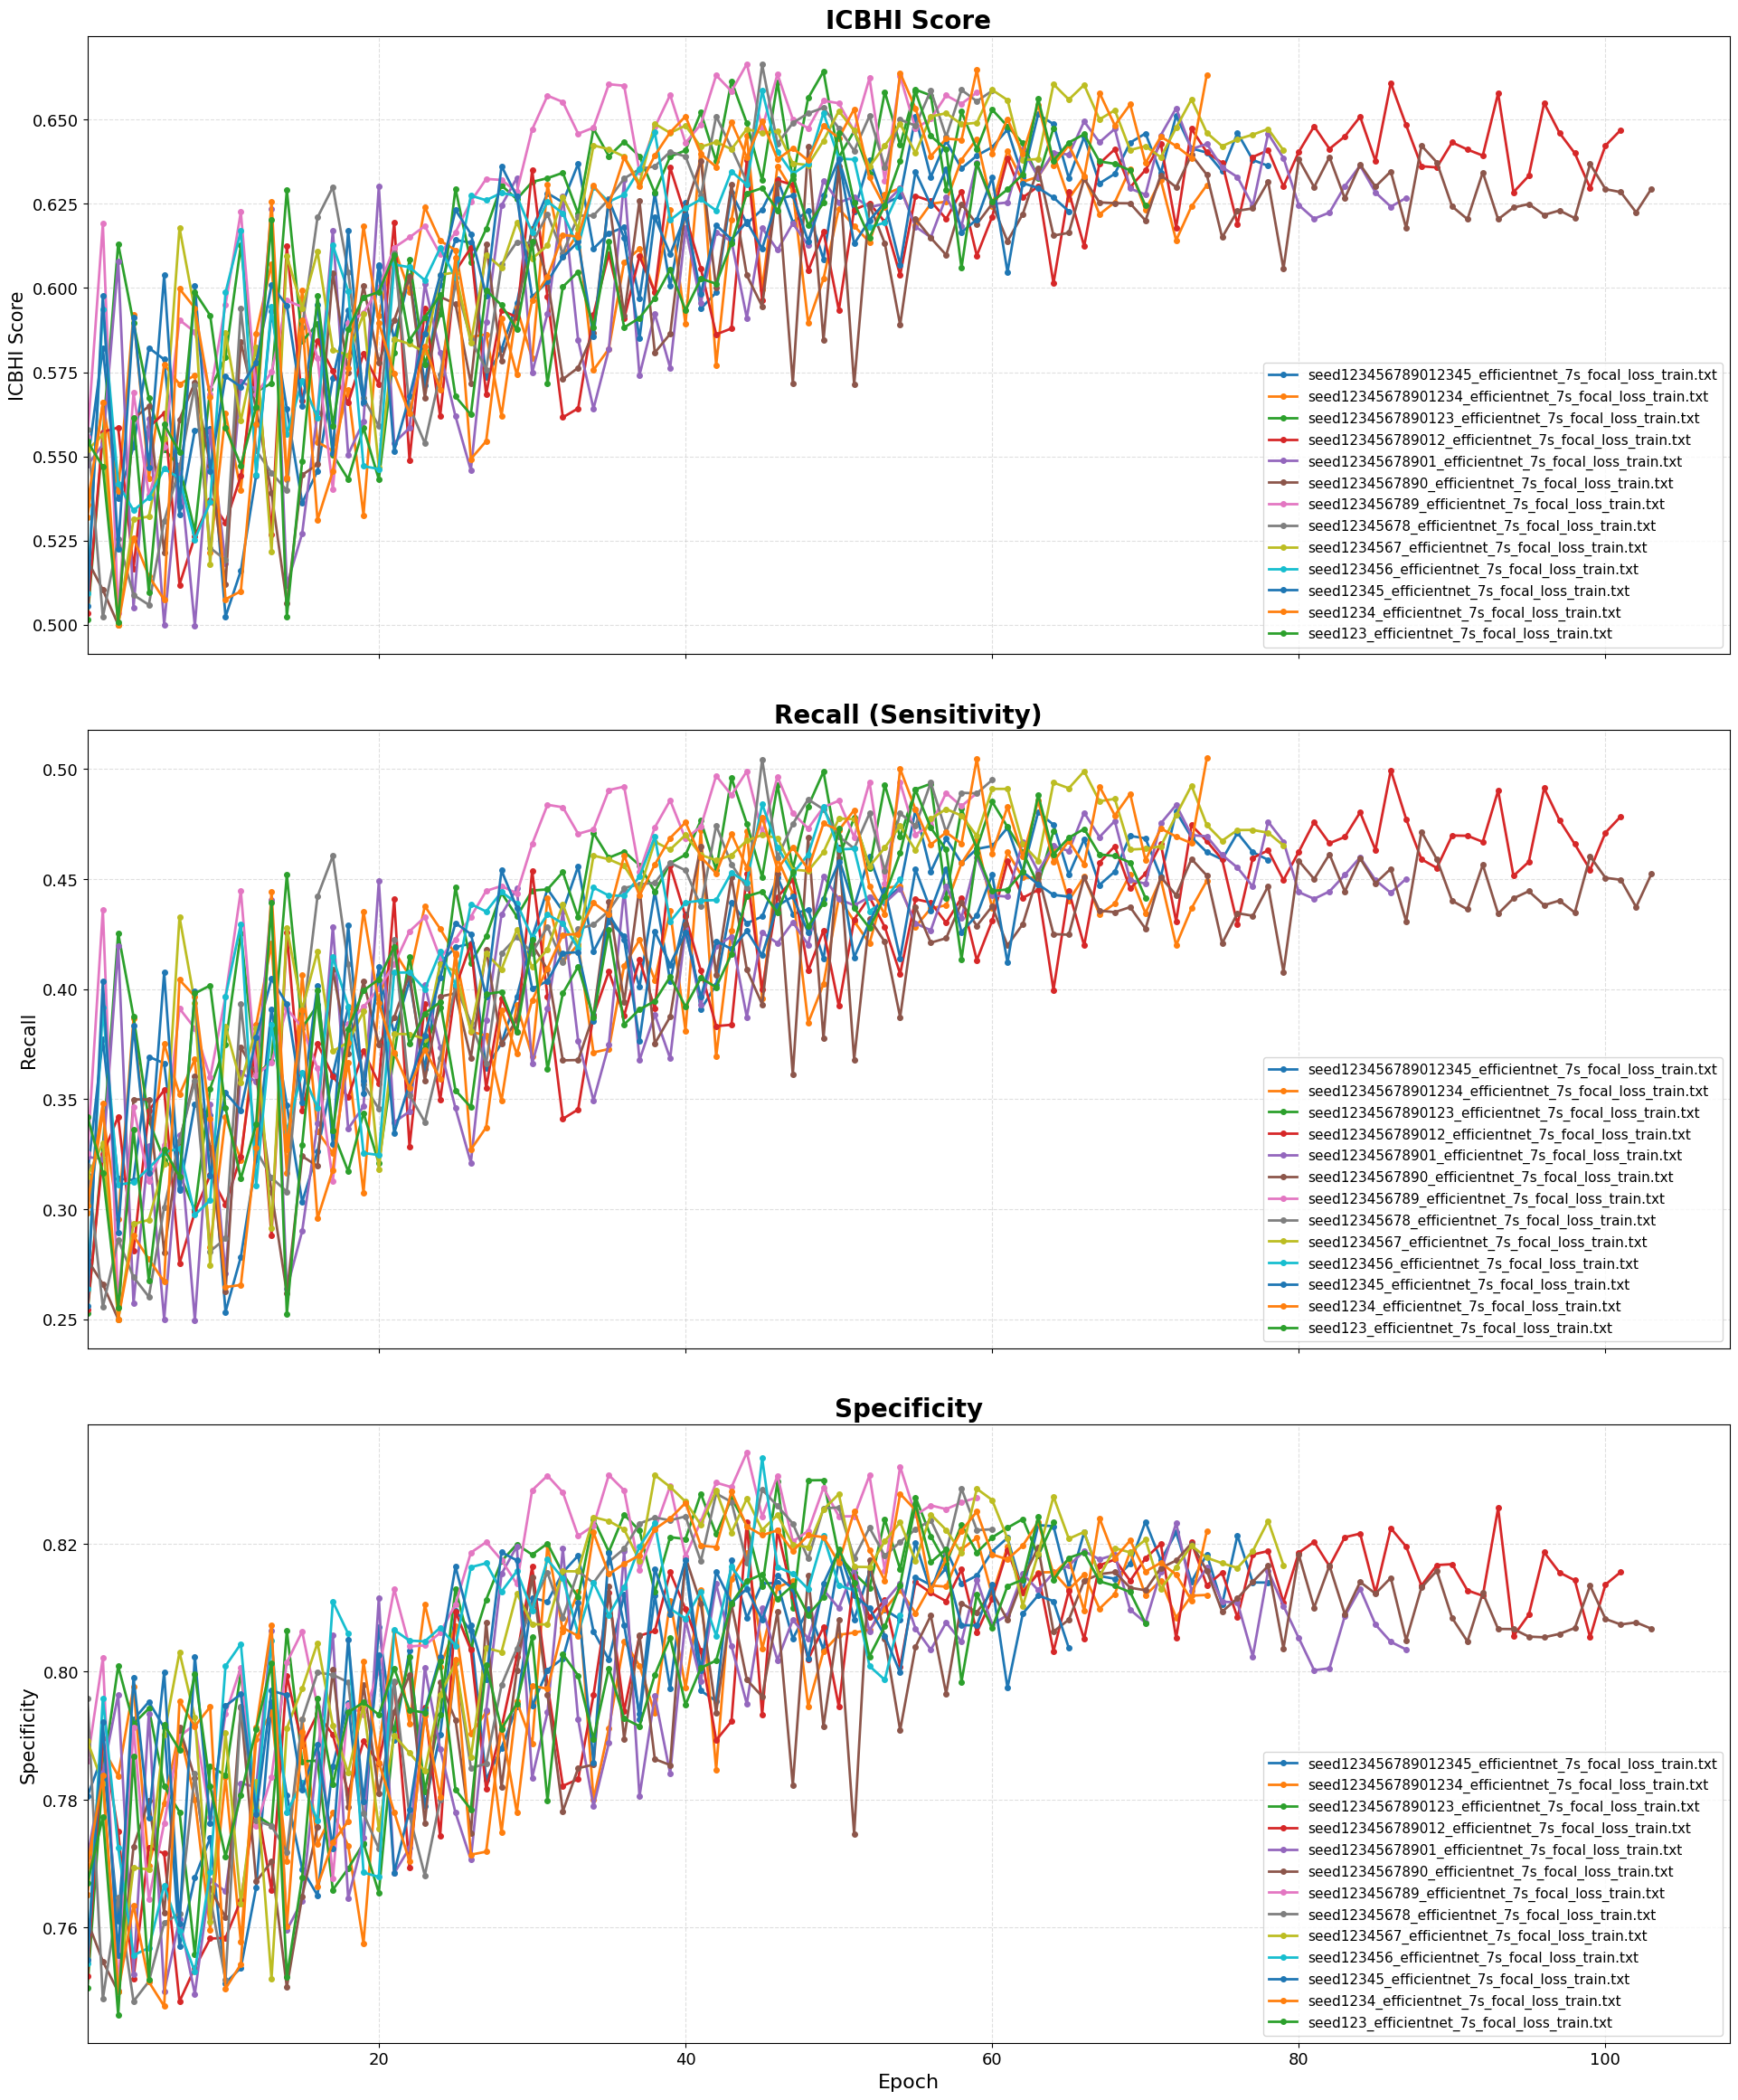

In [5]:
# Obtengo todos los ficheros existentes en un directorio y los paso a la función plot_training_metrics
log_dir = '/app/src/testing/Semilla EfficientNet Focal Loss 7s'
log_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if f.endswith('.txt')]
labels_files = [os.path.basename(f) for f in log_files]

# Ejecuto la función plot_training_metrics con los ficheros obtenidos:
plot_training_metrics(log_files, labels=labels_files)